# ANN Limitations Before CNN Image Classification Practical


## Learning goals
1. Load images from folders.
2. Understand why ANN needs images to be flattened.
3. Observe the loss of spatial structure after flattening.
4. Compare ANN with CNN on the same dataset.

In [2]:
# Operating System (OS) se related functions use karne ke liye library import kar rahe hain.
# Iski madad se folders aur files ke paths ko easily manage kar sakte hain.
import os

# Numerical computations aur arrays ke liye NumPy library import kar rahe hain.
# Images bhi NumPy arrays ki form mein store hoti hain.
import numpy as np

# Images aur graphs display karne ke liye Matplotlib library import kar rahe hain.
# Hum isse dataset aur model ke results visualize karenge.
import matplotlib.pyplot as plt

# TensorFlow library import kar rahe hain.
# Yeh Deep Learning models (ANN, CNN, etc.) banane aur train karne ke liye use hoti hai.
import tensorflow as tf

# TensorFlow ka installed version check aur print kar rahe hain.
# Isse confirm hota hai ke TensorFlow successfully install hai aur kaunsa version use ho raha hai.
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [1]:
import warnings
warnings.filterwarnings('ignore')

## Dataset structure

```text
image_dataset/
├── train/
│   ├── circle/
│   └── square/
└── test/
    ├── circle/
    └── square/
```

Class 0 = circle  
Class 1 = square

In [7]:
# Base folder jahan poora image dataset mojood hai
BASE_DIR = "image_dataset"

# Training images ka folder path
# Model in images se learning karega
TRAIN_DIR = os.path.join(BASE_DIR, "train")

# Testing images ka folder path
# Training ke baad model ki performance check karne ke liye use hoga
TEST_DIR = os.path.join(BASE_DIR, "test")

# Har image ko load karte waqt 32 × 32 pixels mein resize kiya jayega
# Taake sab images ka size same ho aur model easily process kar sake
IMG_SIZE = (32, 32)

# Ek time par model kitni images process karega
# Is example mein har batch mein 32 images hongi
BATCH_SIZE = 32

In [4]:
TRAIN_DIR

'image_dataset\\train'

In [5]:
print(os.getcwd())

C:\Users\OCEAN TECH\Desktop\Session 20\Session 20 b images


In [6]:
print(os.path.exists(TRAIN_DIR))
print(os.path.exists(TEST_DIR))

True
True


In [8]:
# TensorFlow Keras ki Utility (Helper) Function use karke
# training images ko folder se load kar rahe hain.
# Ye function images ko read karta hai, resize karta hai,
# labels assign karta hai aur batches bhi automatically bana deta hai.
train_ds = tf.keras.utils.image_dataset_from_directory(

    # Training images ka folder path
    TRAIN_DIR,

    # Har image ko 32 × 32 pixels mein resize karega
    image_size=IMG_SIZE,

    # Ek batch mein 32 images model ko di jayengi
    batch_size=BATCH_SIZE,

    # Binary classification ke liye labels (0 aur 1) assign karega
    # Kyun ke hamare paas sirf 2 classes hain (Circle aur Square)
    label_mode="binary",

    # Images ko training se pehle randomly shuffle karega
    # Taake model data ka order memorize na kare
    shuffle=True,

    # Random shuffling ko reproducible banane ke liye
    # Har run par same shuffle order maintain karega
    seed=42
)

Found 240 files belonging to 2 classes.


In [9]:
train_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>

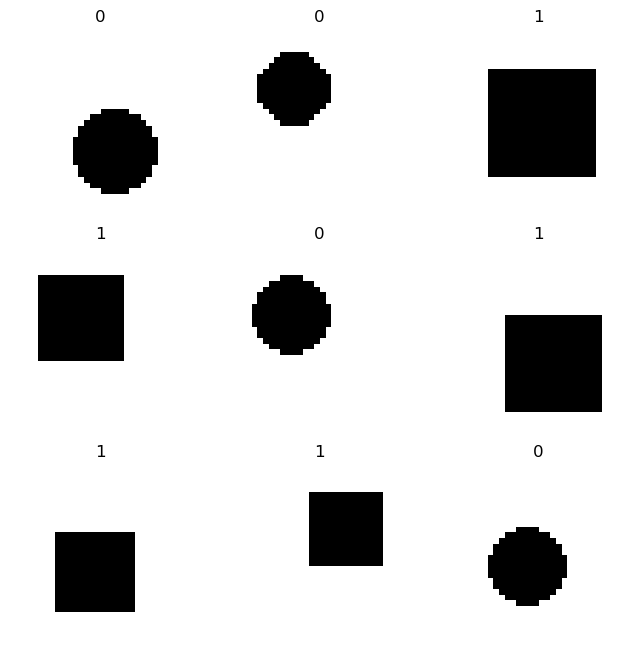

In [11]:

# train_ds se sirf pehla batch (32 images) le rahe hain.
# take(1) ka matlab hai sirf 1 batch load karo.
for images, labels in train_ds.take(1):

    # Images ko display karne ke liye 8×8 inch ka figure bana rahe hain.
    plt.figure(figsize=(8,8))

    # Pehle batch me se sirf pehli 9 images show karenge.
    for i in range(9):

        # 3 Rows aur 3 Columns ka grid bana rahe hain.
        # i+1 current image ki position batata hai.
        plt.subplot(3,3,i+1)

        # Current image ko display kar rahe hain.
        # .numpy() Tensor ko NumPy array me convert karta hai.
        # astype("uint8") image ko original pixel format me dikhata hai.
        plt.imshow(images[i].numpy().astype("uint8"))

        # Har image ke upar uska label (Class) show kar rahe hain.
        plt.title(int(labels[i]))

        # X-axis aur Y-axis ki values hide kar rahe hain.
        plt.axis("off")

    # Saari 9 images screen par display kar do.
    plt.show()

In [12]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

Found 60 files belonging to 2 classes.


In [13]:
class_names = train_ds.class_names
print("Classes:", class_names)

Classes: ['circle', 'square']


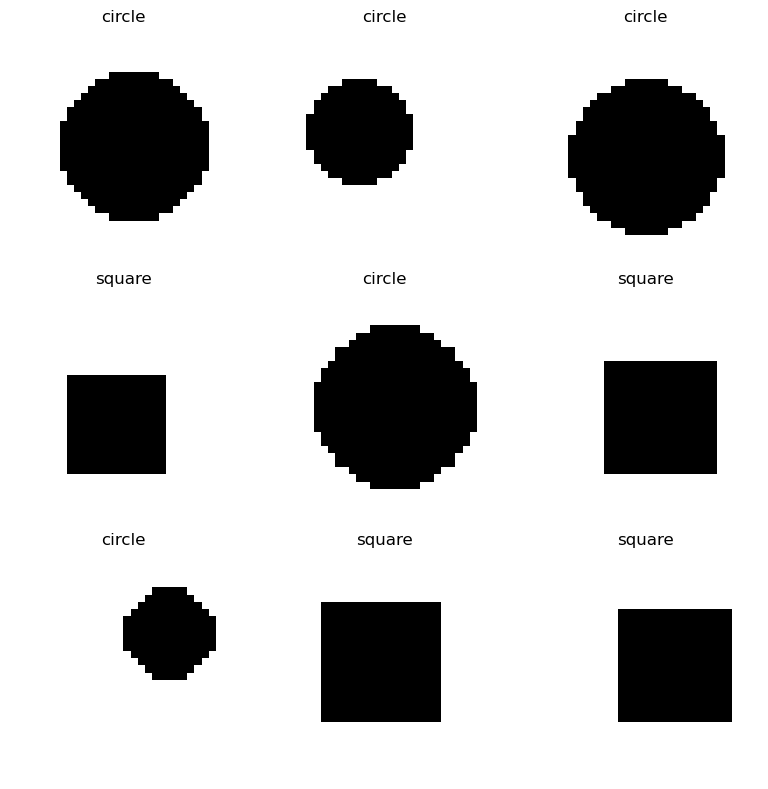

In [14]:
plt.figure(figsize=(8, 8))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i].numpy()[0])])
        plt.axis("off")

plt.tight_layout()
plt.show()

# Part 1: ANN on Image Data

ANN normally expects a one dimensional feature vector.

A 32 × 32 RGB image contains:

```text
32 × 32 × 3 = 3072 pixel values
```

Therefore, before sending the image to a Dense layer, we must flatten it.

## Main ANN limitation

Flattening changes the image from:

```text
height × width × channels
```

into:

```text
one long vector
```

The model no longer explicitly knows which pixels were above, below, or beside one another.

In [15]:
ann_model = tf.keras.Sequential([

    # Input image ki shape define kar rahe hain
    tf.keras.layers.Input(shape=(32, 32, 3)),

    # Pixel values ko 0-255 se 0-1 ke range mein convert karega
    tf.keras.layers.Rescaling(1./255),

    # Image ko 3072 values ke 1D vector mein convert karega
    tf.keras.layers.Flatten(),

    # First Hidden Layer
    tf.keras.layers.Dense(128, activation="relu"),

    # Second Hidden Layer
    tf.keras.layers.Dense(64, activation="relu"),

    # Output Layer
    tf.keras.layers.Dense(1, activation="sigmoid")

])

ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3072)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         393,344 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 401,665 (1.53 MB)

 Trainable params: 401,665 (1.53 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
ann_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [17]:
ann_history = ann_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5
)

Epoch 1/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.5208 - loss: 1.0486 - val_accuracy: 0.5000 - val_loss: 0.8048
Epoch 2/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5500 - loss: 0.7674 - val_accuracy: 0.5000 - val_loss: 0.7004
Epoch 3/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6292 - loss: 0.6278 - val_accuracy: 0.6333 - val_loss: 0.6522
Epoch 4/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5917 - loss: 0.6483 - val_accuracy: 0.6000 - val_loss: 0.7023
Epoch 5/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6417 - loss: 0.6028 - val_accuracy: 0.5833 - val_loss: 0.7244


In [18]:
ann_loss, ann_accuracy = ann_model.evaluate(test_ds)

print("ANN Test Loss:", ann_loss)
print("ANN Test Accuracy:", ann_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5833 - loss: 0.7244
ANN Test Loss: 0.7243817448616028
ANN Test Accuracy: 0.5833333134651184


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


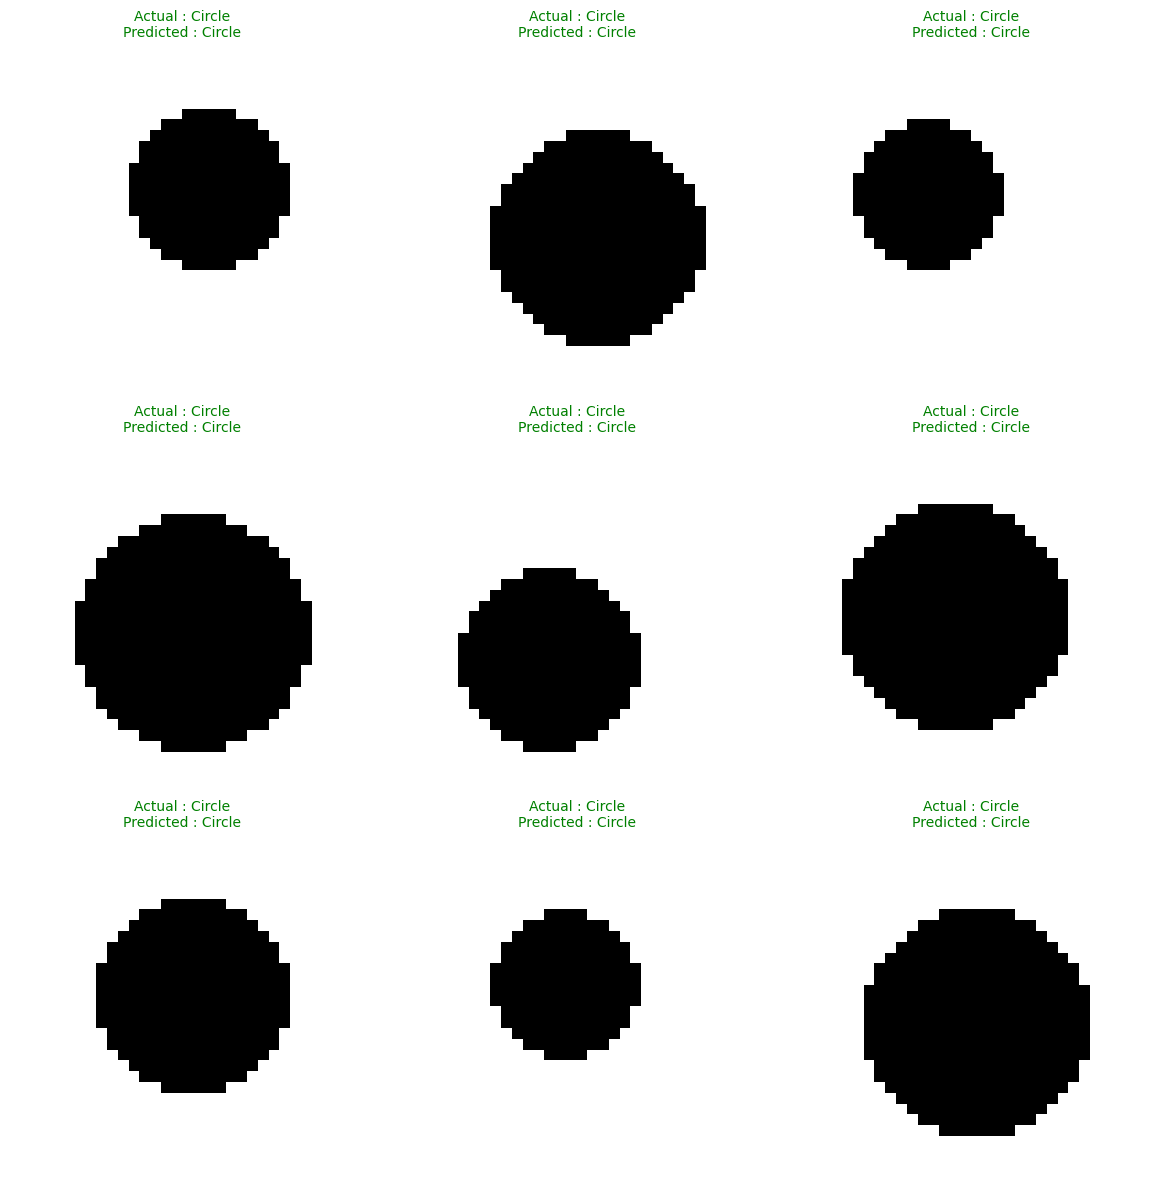

In [19]:

# Class Names
class_names = ["Circle", "Square"]

# Test Dataset ka pehla batch le rahe hain
for images, labels in test_ds.take(1):

    # Model se prediction le rahe hain
    predictions = ann_model.predict(images)

    plt.figure(figsize=(12, 12))

    # Pehli 9 images show karenge
    for i in range(9):

        plt.subplot(3, 3, i + 1)

        # Original Image Display
        plt.imshow(images[i].numpy().astype("uint8"))

        # Actual Label
        actual = class_names[int(labels[i].numpy()[0])]

        # Predicted Label
        predicted = class_names[int(predictions[i] > 0.5)]

        # Green agar prediction sahi ho
        if actual == predicted:
            color = "green"
        else:
            color = "red"

        plt.title(
            f"Actual : {actual}\nPredicted : {predicted}",
            color=color,
            fontsize=10
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()

    break

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


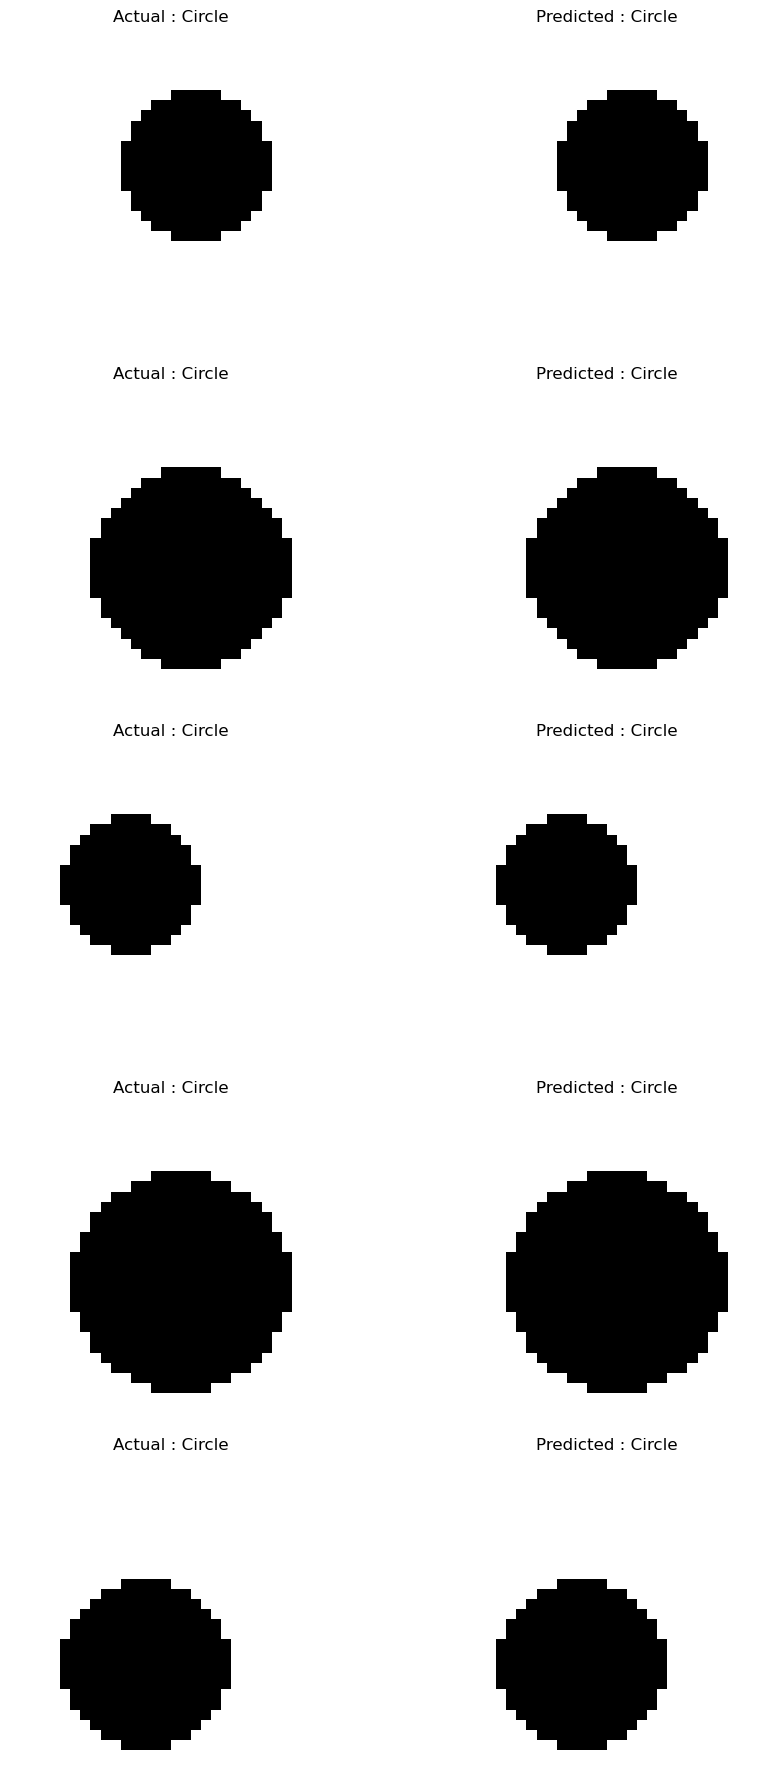

In [20]:
for images, labels in test_ds.take(1):

    predictions = ann_model.predict(images)

    plt.figure(figsize=(10,18))

    for i in range(5):

        # Actual Image
        plt.subplot(5,2,2*i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f"Actual : {class_names[int(labels[i])]}")
        plt.axis("off")

        # Predicted Result
        plt.subplot(5,2,2*i+2)
        plt.imshow(images[i].numpy().astype("uint8"))

        predicted = class_names[int(predictions[i] > 0.5)]

        plt.title(f"Predicted : {predicted}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

    break

## ANN limitations 

1. **Flattening removes the original 2D structure.**
2. **Every Dense neuron connects to every input value**, creating many parameters.
3. ANN does not naturally detect local patterns such as edges and corners.
4. It is less efficient for larger images.
5. It is more sensitive to object position and image variation.

# Part 2: CNN on the Same Images

CNN keeps the image in its original height × width × channels format.

Convolution layers learn local patterns such as:

- edges
- corners
- curves
- shapes
- textures

In [21]:
cnn_model = tf.keras.Sequential([

    # Model ko batata hai ke har input image ki shape 32 × 32 × 3 hai
    # 32 = height, 32 = width, 3 = RGB channels
    tf.keras.layers.Input(shape=(32, 32, 3)),

    # Pixel values ko 0–255 se 0–1 range mein normalize karega
    tf.keras.layers.Rescaling(1./255),

    # 16 filters image se basic features, jaise edges aur lines, learn karenge
    # (3, 3) har filter/kernel ka size hai
    tf.keras.layers.Conv2D(
        16,
        (3, 3),
        activation="relu"
    ),

    # Feature maps ka size chhota karega
    # Important features rakhega aur computation kam karega
    tf.keras.layers.MaxPooling2D(),

    # 32 filters pehle se zyada detailed features learn karenge
    # Jaise curves aur shapes
    tf.keras.layers.Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),

    # Feature maps ko dobara reduce karega
    tf.keras.layers.MaxPooling2D(),

    # 2D feature maps ko 1D vector mein convert karega
    # Taake Dense layer ko input diya ja sake
    tf.keras.layers.Flatten(),

    # Hidden Dense layer with 64 neurons
    tf.keras.layers.Dense(
        64,
        activation="relu"
    ),

    # Binary classification ki output layer
    # Circle ya Square ke liye probability degi
    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

# Model ki layers, output shapes aur parameters show karega
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)              │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 30, 30, 16)          │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 13, 13, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 1152)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 78,945 (308.38 KB)

 Trainable params: 78,945 (308.38 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [23]:
cnn_history = cnn_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5
)

Epoch 1/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.6250 - loss: 0.6453 - val_accuracy: 0.6167 - val_loss: 0.6027
Epoch 2/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8583 - loss: 0.4835 - val_accuracy: 0.7167 - val_loss: 0.4876
Epoch 3/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9250 - loss: 0.3470 - val_accuracy: 0.7500 - val_loss: 0.3927
Epoch 4/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9542 - loss: 0.2381 - val_accuracy: 0.8333 - val_loss: 0.2740
Epoch 5/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9833 - loss: 0.1422 - val_accuracy: 1.0000 - val_loss: 0.1385


In [24]:
cnn_loss, cnn_accuracy = cnn_model.evaluate(test_ds)

print("CNN Test Loss:", cnn_loss)
print("CNN Test Accuracy:", cnn_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 1.0000 - loss: 0.1385
CNN Test Loss: 0.13848717510700226
CNN Test Accuracy: 1.0


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


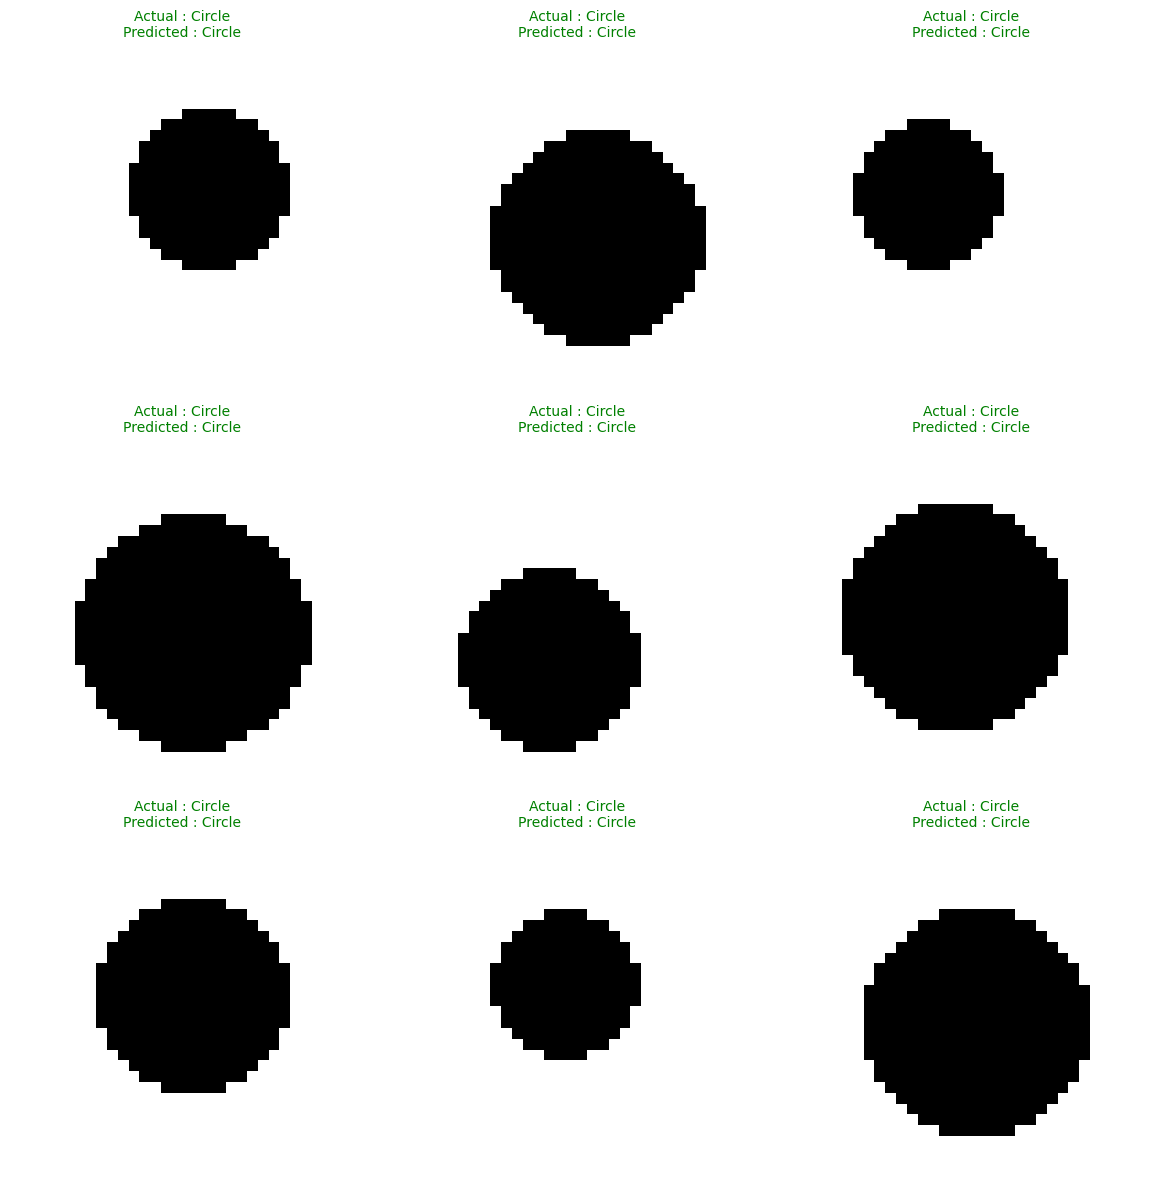

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Class Names
class_names = ["Circle", "Square"]

# Test Dataset ka pehla batch le rahe hain
for images, labels in test_ds.take(1):

    # Model se prediction le rahe hain
    predictions = cnn_model.predict(images)

    plt.figure(figsize=(12, 12))

    # Pehli 9 images show karenge
    for i in range(9):

        plt.subplot(3, 3, i + 1)

        # Original Image Display
        plt.imshow(images[i].numpy().astype("uint8"))

        # Actual Label
        actual = class_names[int(labels[i].numpy()[0])]

        # Predicted Label
        predicted = class_names[int(predictions[i] > 0.5)]

        # Green agar prediction sahi ho
        if actual == predicted:
            color = "green"
        else:
            color = "red"

        plt.title(
            f"Actual : {actual}\nPredicted : {predicted}",
            color=color,
            fontsize=10
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()

    break

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


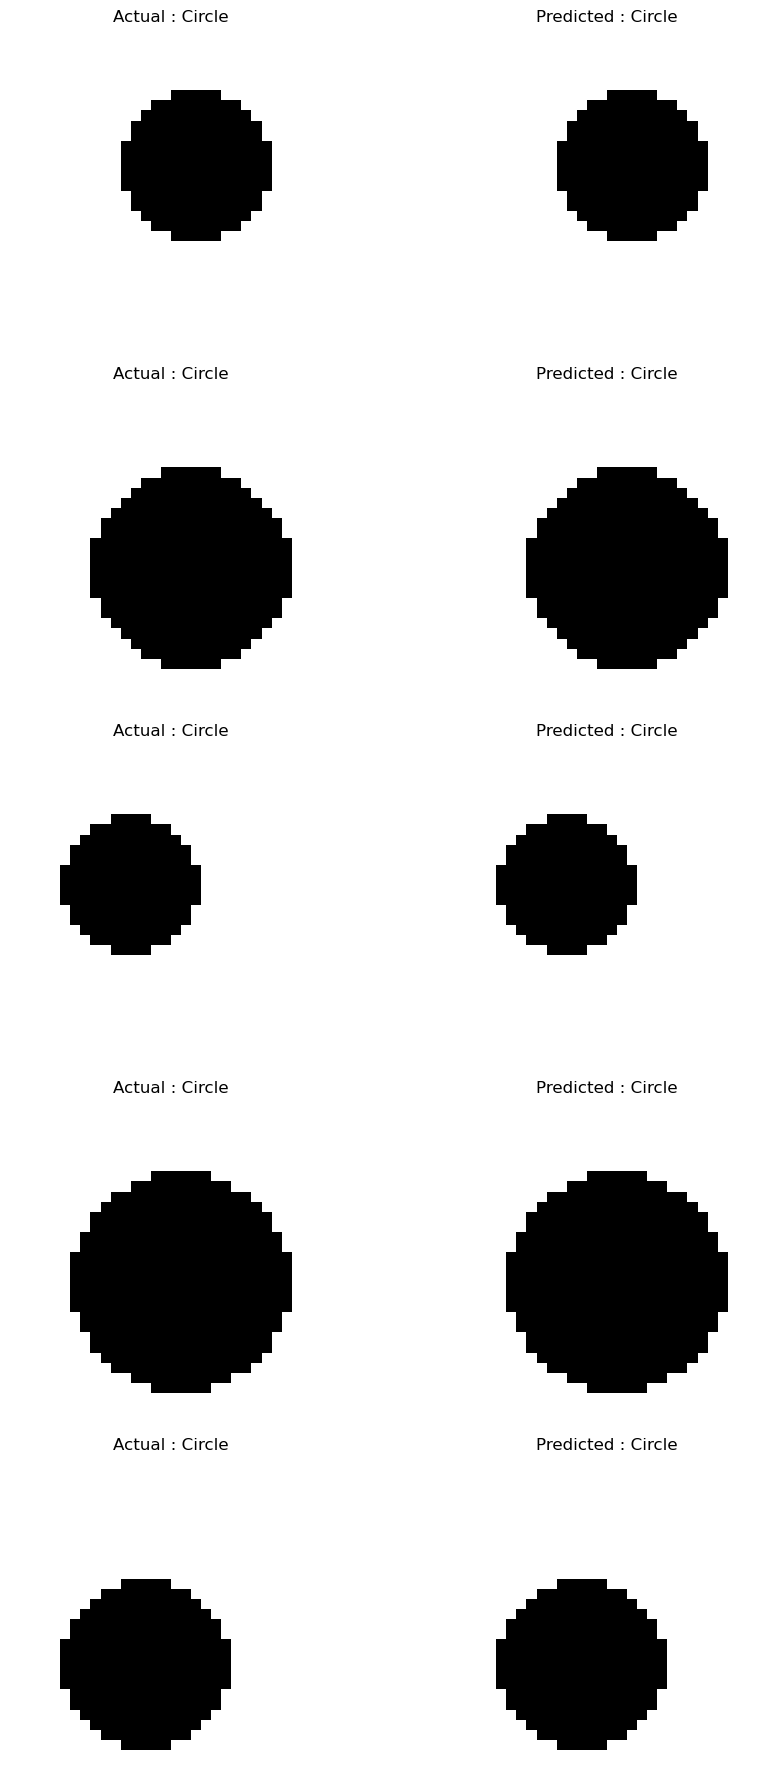

In [26]:

class_names = ["Circle", "Square"]

for images, labels in test_ds.take(1):

    predictions = cnn_model.predict(images)

    plt.figure(figsize=(10,18))

    for i in range(5):

        # Actual Image
        plt.subplot(5,2,2*i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f"Actual : {class_names[int(labels[i])]}")
        plt.axis("off")

        # Predicted Result
        plt.subplot(5,2,2*i+2)
        plt.imshow(images[i].numpy().astype("uint8"))

        predicted = class_names[int(predictions[i] > 0.5)]

        plt.title(f"Predicted : {predicted}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

    break

# Compare ANN and CNN

The exact accuracy can vary slightly, but the conceptual difference remains important:

| ANN | CNN |
|---|---|
| Requires flattening | Works with image structure |
| Does not explicitly preserve spatial relationships | Learns spatial features |
| Dense connections create many parameters | Uses shared filters |
| Weak for complex image patterns | Designed for image tasks |